# Market - sentiment independence

In [1]:
import os
import sys
# ABY FUNGOVALI relativne importy
root_path = os.path.abspath(os.path.join('..', '..')) 
if root_path not in sys.path:
    sys.path.insert(0, root_path)
__package__ = "source.analysis" 

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from ..data.model_data import return_data
from ..data.sentiment import return_sentiment_agg_pivot
import pandas as pd
import plotly.graph_objects as go

In [101]:
WITH_LABEL = False
data = return_data(
    IS_QA_division=False,
    qa_options="just_answers",
    with_label=WITH_LABEL,
    word_limit=200,
    market_data="all",
).set_index("date")
sentiment_columns = (
    data[
        sorted(
            [
                c
                for c in list(data.columns)
                if any(x in c for x in ["finbert", "roberta"])
            ],
            key=lambda x: tuple(reversed(x.split("_"))),
        )
    ]
).columns

In [102]:
data.columns

Index(['pc1', 'STOXX50_x', 'MP_pm', 'CBI_pm', 'MP_median', 'CBI_median',
       'OIS_1M', 'OIS_3M', 'OIS_6M', 'OIS_1Y', 'DE2Y', 'DE10Y', 'IT2Y', 'FR2Y',
       'ES2Y', 'ES10Y', 'FR10Y', 'IT10Y', 'STOXX50_y', 'MRO', 'DF announced',
       'DF effective', 'Wu-Xia shadow rate', 'MRO announced', 'MRO effective',
       'finbert_max', 'roberta_max', 'finbert_mean', 'roberta_mean',
       'finbert_min', 'roberta_min', 'finbert_std', 'roberta_std'],
      dtype='str')

In [ ]:
data_labeled = return_data(with_label=True, market_data="all")

# How many chunks per topic?
# You need to know if some topics are too sparse to be reliable
print(data_labeled[[c for c in data_labeled.columns if 'IS_' in c and '_mean' in c]].iloc[23])

In [ ]:
from ..data.connection import conn
sql = f"""SELECT DATE(st.date) date, ch.rowid, CASE ch.part WHEN 0 THEN "IS" ELSE "QA" END part, ch.is_question=1 is_question, ch.chunk, se.score, sm.name sentiment_model
FROM sentiments se
JOIN chunks ch ON ch.rowid = se.chunk_rowid
JOIN statements st ON st.rowid = ch.statement_id
JOIN sentiment_models sm ON sm.rowid = se.model_id
WHERE ch.chunk_limit = ?
ORDER BY st.date, ch.part, ch.chunk_id;
"""
mapper = pd.read_sql(sql, conn, parse_dates="date", params=(50,)).set_index("rowid")

In [ ]:
data.columns

In [ ]:
from ..nlp.make_sentiment import chunk_sentiment_maker

df = chunk_sentiment_maker("finbert", 50,  apply_divisor=True)

In [ ]:
df

In [ ]:
df["date"] = df["chunk_rowid"].map(mapper.query("sentiment_model == 'finbert'")["date"])
df["part"] = df["chunk_rowid"].map(mapper.query("sentiment_model == 'finbert'")["part"])
df["is_question"] = df["chunk_rowid"].map(mapper.query("sentiment_model == 'finbert'")["is_question"])
df["sentiment_model"] = "finbert"


In [ ]:
grouping_columns = ["date", "part"]
grouping_columns += ["is_question", "sentiment_model"]
data_agg = df.groupby(grouping_columns).agg(
    {"score": ["min", "mean", "max", "std"]}
)
data_agg.columns = data_agg.columns.droplevel(0)
data_agg = data_agg.reset_index()
data_agg.columns.name = None

In [ ]:
from ..data.sentiment import label_formatter

In [ ]:
data_agg["label"] = data_agg[["part", "sentiment_model"]].apply(
    (lambda x: label_formatter(x["part"], x["sentiment_model"])),
    axis=1,
)

agg_data = data_agg[data_agg["is_question"] == False]
agg_data.drop(columns=["is_question"], inplace=True)
# Preklopíme tabuľku (pivot)

df_pivot: pd.DataFrame = agg_data.pivot(
    index="date", columns="label", values=["max", "mean", "min", "std"]
)
# Zlúčime viacúrovňové názvy stĺpcov do jedného (napr. 'mean_QA_MP')
df_pivot.columns = [f"{col[1]}_{col[0]}" for col in df_pivot.columns]
df_pivot = df_pivot.reset_index()

df_pivot = df_pivot.fillna(df_pivot.mean(), inplace=True)

In [ ]:
df_pivot.columns

In [ ]:
fig, ax = plt.subplots()
fig.set_figwidth(20)

sns.lineplot(sentiment_data, x="date",y="finbert_IS_mean", label="finbert", ax=ax)
sns.lineplot(df_pivot, x="date",y="finbert_IS_mean", label="finbert divided", ax=ax)
ax.grid()
ax.legend()

In [ ]:
data[["MRO", "MRO announced"]]

In [ ]:
data["finbert_gap"] = data["finbert_IS_mean"] - data["finbert_QA_mean"]
data["roberta_gap"] = data["roberta_IS_mean"] - data["roberta_QA_mean"]

In [ ]:
plt.figure(figsize=(15,10))
sns.lineplot(data=data, x=data.index, y="finbert_gap", label="finbert gap")
sns.lineplot(data=data, x=data.index, y="roberta_gap", label="roberta gap")
plt.axhline(color="red",linestyle="dashed")
plt.grid()

In [61]:
data.columns

Index(['pc1', 'STOXX50_x', 'MP_pm', 'CBI_pm', 'MP_median', 'CBI_median',
       'OIS_1M', 'OIS_3M', 'OIS_6M', 'OIS_1Y', 'DE2Y', 'DE10Y', 'IT2Y', 'FR2Y',
       'ES2Y', 'ES10Y', 'FR10Y', 'IT10Y', 'STOXX50_y', 'MRO', 'DF announced',
       'DF effective', 'Wu-Xia shadow rate', 'MRO announced', 'MRO effective',
       'finbert_max', 'roberta_max', 'finbert_mean', 'roberta_mean',
       'finbert_min', 'roberta_min', 'finbert_std', 'roberta_std', 'MRO_diff',
       'roberta_mean_diff', 'finbert_mean:11'],
      dtype='str')

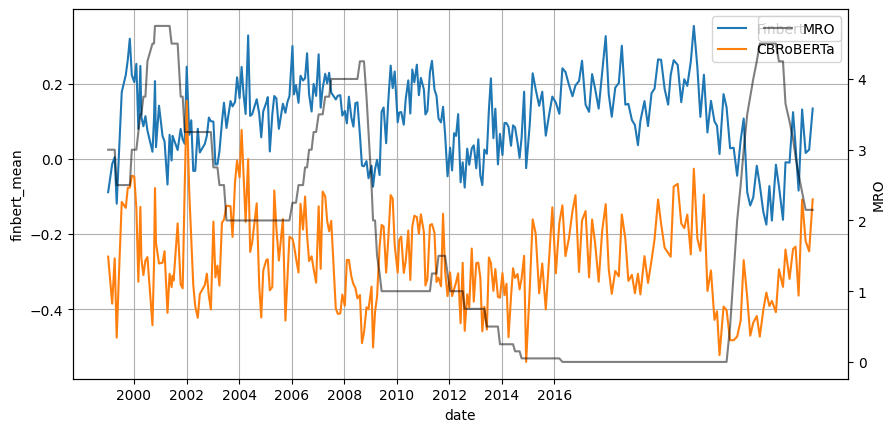

In [129]:
fig, ax = plt.subplots()
fig.set_figwidth(10)
data["MRO_diff"] = data["MRO announced"] - data["MRO"]
data["roberta_mean_diff"] = data["finbert_mean"]
sns.lineplot(
    data,
    x="date",
    y=data["finbert_mean"],
    label="Finbert",
    ax=ax,
)
sns.lineplot(
    data,
    x="date",
    y=data["roberta_mean"],
    label="CBRoBERTa",
    ax=ax,
)

sns.lineplot(
    data,
    x="date",
    y="MRO",
    label="MRO",
    color="black",
    alpha=0.5,
    ax=ax.twinx(),
)
ax.set_xticks([f"{year}-01-01" for year in range(2000, 2017, 2)], range(2000, 2017, 2))
ax.grid()

date
1999-01-07         NaN
1999-03-04         NaN
1999-04-08         NaN
1999-05-06         NaN
1999-06-02         NaN
                ...   
2025-04-17   -0.293526
2025-06-05   -0.340396
2025-07-24   -0.241056
2025-09-11   -0.319115
2025-10-30   -0.239798
Name: roberta_mean, Length: 272, dtype: float64

<Axes: xlabel='finbert_mean', ylabel='MRO_diff'>

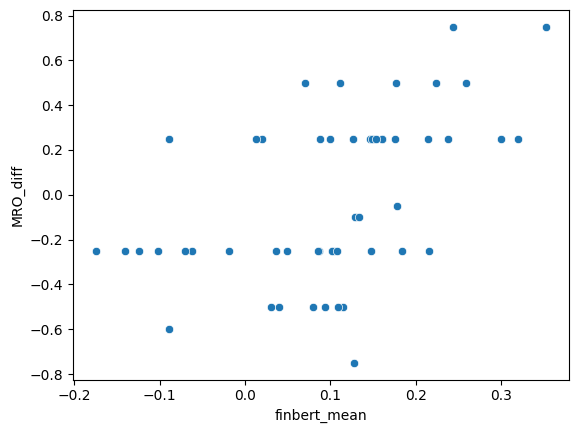

In [54]:
sns.scatterplot(data.query("MRO_diff != 0"), x=data["finbert_mean"].shift(11), y="MRO_diff")

In [59]:
data["finbert_mean:11"] = data["finbert_mean"].shift(11)
data.query("MRO_diff != 0")[["finbert_mean:11","MRO_diff"]].corr()

,finbert_mean:11,MRO_diff
finbert_mean:11,1.000000,0.505625
MRO_diff,0.505625,1.000000


In [ ]:
data['sentiment_gap'] = data['finbert_IS_mean'] - data['finbert_QA_mean']
data["roberta_QA_mean_diff"] = data["roberta_QA_mean"].diff()

In [ ]:
sns.scatterplot(data.loc['2014-01-01':'2021-12-31'], x="roberta_IS_mean",y='Wu-Xia shadow rate')

In [ ]:
# Zameraj sa na obdobie 'Zero Lower Bound'
zlb_period = data.loc['2014-01-01':'2021-12-31']
correlation_zlb = zlb_period.corr()['Wu-Xia shadow rate'].loc[sentiment_columns]
print(pd.DataFrame(correlation_zlb).sort_values("Wu-Xia shadow rate").to_csv())

In [ ]:
# Zameraj sa na obdobie 'Zero Lower Bound'
before_zlb_period = data.loc[:'2014-01-01']
correlation_bzlb = before_zlb_period.corr()['MRO_diff'].loc[sentiment_columns]
print(pd.DataFrame(correlation_bzlb).to_csv())

In [ ]:
# Zameraj sa na obdobie 'Zero Lower Bound'
after_zlb_period = data.loc['2021-12-31':]
correlation_azlb = after_zlb_period.corr()['MRO_diff'].loc[sentiment_columns]
print(pd.DataFrame(correlation_azlb).to_csv())

In [ ]:
fig, ax1 = plt.subplots(figsize=(12,6))

# Os X: Čas, Os Y1: Sentiment
ax1.bar(data.index, data['finbert_IS_mean'], color='blue', alpha=0.3, label='QA Sentiment')
ax1.set_ylabel('Sentiment Score')

# Druhá os Y2: Zmena sadzieb (Shadow rate alebo Euribor)
ax2 = ax1.twinx()
ax2.plot(data.index, data['Wu-Xia shadow rate'], color='red', label='Shadow Rate')
ax2.set_ylabel('Shadow Rate (%)')

plt.title("Sentiment vs. Real Policy Rate Evolution")
plt.show()

In [ ]:
# 1. Príprava dát a výpočet zmeny sentimentu
new_data = data.sort_index()
COLUMN = 'roberta_IS_mean'
COLUMN_Y = "MRO_diff"
new_data[f"{COLUMN}_delta"] = data[COLUMN].diff()


# 2. Rozdelíme do decilov a ZÍSKAME HRANICE (bins)
# retbins=True nám vráti pole hodnôt, ktoré ohraničujú decily
new_data['sentiment_decile'], bins = pd.qcut(new_data[f"{COLUMN}_delta"], 4, retbins=True, labels=False)
print(new_data['sentiment_decile'].value_counts())
# 3. Výpočet priemeru pre každý decil
decile_analysis = new_data.groupby('sentiment_decile')[COLUMN_Y].mean()

# 4. Vytvorenie pekných labels pre os x (formát: "od, do")
# bins obsahuje 11 hodnôt pre 5 intervalov
bin_labels = [f"({bins[i]:.2f}, {bins[i+1]:.2f}]" for i in range(len(bins)-1)]

# 5. Vizualizácia
plt.figure(figsize=(12, 6))
ax = decile_analysis.plot(kind='bar', color='skyblue')

plt.axhline(0, color='red', linestyle='--')

# Nastavenie x-ticks na reálne hodnoty sentimentu
plt.xticks(range(4), bin_labels, rotation=45, ha='right')

plt.title("Reakcia trhu podľa reálnych hodnôt zmeny sentimentu")
plt.xlabel(f"Interval zmeny sentimentu ({COLUMN} diff)")
plt.ylabel("Priemerná hodnota OIS_1M (bp)")

plt.tight_layout()
plt.show()

In [ ]:
# 1. Časový rad s vyznačeným thresholdom
threshold = data["OIS_3M"].abs().quantile(0.7)
data["OIS_3M_above_threshold"] = data["OIS_3M"].abs() > threshold
new_data = data.query("OIS_3M_above_threshold")
fig, ax = plt.subplots(figsize=(12, 5))

sns.lineplot(
    new_data, x="date", y="OIS_3M", label="OIS_3M", color="black", alpha=1, ax=ax
)
ax.set_ylim(-15.5,15.5)
ax2 = ax.twinx()
sns.scatterplot(new_data,x="date", y=new_data["roberta_IS_mean"].diff(),alpha=0.6, label="roberta_IS_mean diff", color="green", ax=ax2)
ax2.set_ylim(-0.55,0.55)
ax.axhline(threshold, color="red", linestyle="--", label="30% Threshold")
ax.axhline(-threshold, color="red", linestyle="--")
ax.legend(loc="upper left")
ax2.grid()
ax.set_xticks(new_data.index,"")
ax.grid(axis="x",alpha=0.4)
None

In [ ]:
COLUMN_Y = "OIS_3M"
COLUMN = "roberta_QA_mean"

threshold = data[COLUMN_Y].abs().quantile(0.7)
data[f"{COLUMN_Y}_above_threshold"] = data[COLUMN_Y].abs() > threshold
new_data = data.query(f"{COLUMN_Y}_above_threshold")

plt.axhline(0,linestyle="dashed",color="red")
plt.axvline(0,linestyle="dashed",color="red")
sns.scatterplot(
    new_data, x=new_data[COLUMN].diff(), y=COLUMN_Y, color="black", alpha=1
)
plt.xlabel(f"CB{COLUMN} rozdiel medzi tlačovkami")
print(threshold)

In [ ]:
print("Autokorelácia (lag 1):", data['finbert_IS_MP_mean_diff'].autocorr())